# Mini-proyecto: Predecir resultados de la F1 usando carreras pasadas
**Objetivo:** Predecir la posicion final (top 3, top 10) usando datos de carreras anteriores

El modelo esta entrenado para responder la pregunta:
__¿Quiénes estarán en el podio en esta carrera específica (ej: Bahrain)?__


In [ ]:
import os
import fastf1
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report

from fastf1.events import get_event_schedule

In [4]:
# Enable FastF1 caching
cache_folder = 'cache_folder'
if not os.path.exists(cache_folder):
    os.makedirs(cache_folder)

fastf1.Cache.enable_cache(cache_folder)

## Paso 1: Obtener datos de varias carreras
Utilizando |FastF1| para recorrer múltiples carreras de una o varias temporadas.

In [12]:
# Quick test

# Comprobar el calendario de una temporada
def check_season_schedule(year):
    try:
        schedule = fastf1.get_event_schedule(year)
        print(schedule.head())
    except Exception as e:
        print(f"No se pudo cargar el calendario para {year}: {e}")

# Comprobar calendarios para 2022 y 2023
check_season_schedule(2023)
check_season_schedule(2022)

logger      WARNING 	Failed to load schedule from FastF1 backend!
req            INFO 	No cached data found for season_schedule. Loading data...
_api           INFO 	Fetching season schedule...
logger      WARNING 	Failed to load schedule from F1 API backend!
logger      WARNING 	Failed to load schedule from Ergast API backend!


No se pudo cargar el calendario para 2023: Failed to load any schedule data.


logger      WARNING 	Failed to load schedule from FastF1 backend!
req            INFO 	No cached data found for season_schedule. Loading data...
_api           INFO 	Fetching season schedule...
logger      WARNING 	Failed to load schedule from F1 API backend!
logger      WARNING 	Failed to load schedule from Ergast API backend!


No se pudo cargar el calendario para 2022: Failed to load any schedule data.


In [15]:
# Obtener datos de una carrera
def get_race_data(year, round_name):
    try:
        session = fastf1.get_session(year, round_name, 'R')
        session.load()
        results = session.results
        results['Race'] = round_name
        results['Year'] = year
        return results
    except Exception as e:
        print(f"Error en {year} - Ronda {round_name}: {e}")
        return pd.DataFrame()

# Lista explícita de carreras para 2022 y 2023
carreras_2022 = [
    'Bahrain', 'Saudi Arabia', 'Australia', 'Emilia Romagna', 'Miami',
    'Spain', 'Monaco', 'Azerbaijan', 'Canada', 'Great Britain',
    'Austria', 'France', 'Hungary', 'Belgium', 'Netherlands',
    'Italy', 'Singapore', 'Japan', 'United States', 'Mexico',
    'Brazil', 'Abu Dhabi'
]

carreras_2023 = [
    'Bahrain', 'Saudi Arabia', 'Australia', 'Azerbaijan', 'Miami',
    'Monaco', 'Spain', 'Canada', 'Austria', 'Great Britain',
    'Hungary', 'Belgium', 'Netherlands', 'Italy', 'Singapore',
    'Japan', 'Qatar', 'United States', 'Mexico', 'Brazil', 'Las Vegas', 'Abu Dhabi'
]

# Obtener datos de 2022 y 2023
df_2022 = pd.concat([get_race_data(2022, carrera) for carrera in carreras_2022], ignore_index=True)
df_2023 = pd.concat([get_race_data(2023, carrera) for carrera in carreras_2023], ignore_index=True)

# Combinar todo en un solo DataFrame
df_all = pd.concat([df_2022, df_2023], ignore_index=True)

#Limpiar nulos y continuar como antes...
print(df_all[['DriverNumber', 'Abbreviation', 'Position', 'GridPosition', 'TeamName', 'Race', 'Year']].head())



core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 16 completed the race distance 00:00.050000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '44', '63', '20', '77', '31', '22', '14', '24', '47', 

  DriverNumber Abbreviation  Position  ...      TeamName     Race  Year
0           16          LEC       1.0  ...       Ferrari  Bahrain  2022
1           55          SAI       2.0  ...       Ferrari  Bahrain  2022
2           44          HAM       3.0  ...      Mercedes  Bahrain  2022
3           63          RUS       4.0  ...      Mercedes  Bahrain  2022
4           20          MAG       5.0  ...  Haas F1 Team  Bahrain  2022

[5 rows x 7 columns]


In [16]:
print(df_all[['DriverNumber', 'Abbreviation', 'Position', 'GridPosition', 'TeamName', 'Race']])

    DriverNumber Abbreviation  Position  GridPosition      TeamName       Race
0             16          LEC       1.0           1.0       Ferrari    Bahrain
1             55          SAI       2.0           3.0       Ferrari    Bahrain
2             44          HAM       3.0           5.0      Mercedes    Bahrain
3             63          RUS       4.0           9.0      Mercedes    Bahrain
4             20          MAG       5.0           7.0  Haas F1 Team    Bahrain
..           ...          ...       ...           ...           ...        ...
875            2          SAR      16.0          20.0      Williams  Abu Dhabi
876           24          ZHO      17.0          19.0    Alfa Romeo  Abu Dhabi
877           55          SAI      18.0          16.0       Ferrari  Abu Dhabi
878           77          BOT      19.0          18.0    Alfa Romeo  Abu Dhabi
879           20          MAG      20.0          17.0  Haas F1 Team  Abu Dhabi

[880 rows x 6 columns]


## Paso 2: Crear columnas para el modelo
Se definen variables que se pueden usar como features:
- __GridPosition__: Posición de salida
- __TeamName__: codificada como número
- __Abrevviation__: piloto, codificado también
- Agregables: puntos antes de la carrera, promedio de posición, etc.

In [5]:
df = df_all.copy()
df = df.dropna(subset=['Position']) # eliminamos DNFs

# Convertir a int
df['Position'] = df['Position'].astype(int)
df['GridPosition'] = df['GridPosition'].astype(int)

# Codificar equipos y pilotos
df['TeamCode'] = LabelEncoder().fit_transform(df['TeamName'])
df['DriverCode'] = LabelEncoder().fit_transform(df['Abbreviation'])

# Variable objetivo: top 3
df['Top3'] = df['Position'].apply(lambda x: 1 if x <= 3 else 0)

Cuando _Top3_ = 1, esto significa que el piloto termino en el podio (posicion 1, 2 o 3)

Entonces cuando el modelo predice un 1, está diciendo: "creo que este piloto va a estar en el podio".

## Paso 3: Entrenar modelo simple

In [6]:
features = ['GridPosition', 'TeamCode', 'DriverCode']
X = df[features]
y = df['Top3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8


## Top 5 por probabilidades para una carrera en especifico

In [7]:
# Predecir probabilidades usando solo los features originales
X_test_features = X_test[features]                     # Asegurarse de no incluir columnas extra
y_proba = model.predict_proba(X_test_features)[:,1]    # Probabilidad de clase 1 (Top 3)

# Crear una copia de X_test para agregar las probabilidades y etiquetas
X_test = X_test.copy()
X_test['Proba_Top3'] = y_proba
X_test['Actual'] = y_test.values
X_test['Predicted'] = y_pred

# Unir con informacion util como piloto, carrera y posición final
X_test_full = X_test.merge(
    df[['Abbreviation', 'Race', 'Position']],
    left_index=True, right_index=True
)

# Elegir una carrera especifica
carrera_deseada = "Bahrain"  # Cambiá esto para otra carrera

# Filtrar por esa carrera y mostrar el tp 5 por probabilidad de podio
top5 = (
    X_test_full[X_test_full['Race'] == carrera_deseada]
    .sort_values(by='Proba_Top3', ascending=False)
    .head(5)
)

# Mostrar resultados
print(f"\nTop 5 pilotos con mayor probabilidad de podio en {carrera_deseada}:\n")
print(top5[['Abbreviation', 'Proba_Top3', 'Position', 'Actual']])



Top 5 pilotos con mayor probabilidad de podio en Bahrain:

   Abbreviation  Proba_Top3  Position  Actual
3           LEC        0.99         4       0
4           RUS        0.85         5       0
1           PER        0.16         2       1
11          MAG        0.01        12       0
16          OCO        0.01        17       0


### Identificacion de Errores

In [8]:
# Paso 1: Crear un DataFrame con la comparación entre la predicción y el valor real
results_df = pd.DataFrame({
    'Real': y_test,  # La posición real (1 = top 3, 0 = no top 3)
    'Prediccion': y_pred,  # La predicción del modelo (1 = top 3, 0 = no top 3)
    'Proba_Top3': y_proba,  # Probabilidad de estar en el top 3
})

# Paso 2: Añadir una columna de "Resultado" que indique si fue un acierto o un error
results_df['Resultado'] = results_df.apply(
    lambda row: 'Acierto' if row['Real'] == row['Prediccion'] else 'Error', axis=1
)

# Paso 3: Ver los errores y analizarlos
errores_df = results_df[results_df['Resultado'] == 'Error']
print(errores_df)

    Real  Prediccion  Proba_Top3 Resultado
3      0           1        0.99     Error
1      1           0        0.16     Error
4      0           1        0.85     Error
58     0           1        0.98     Error


C:\Users\Rolando Domínguez\AppData\Local\Temp\ipykernel_29536\305603572.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=results_df, x='Resultado', palette='Set2')


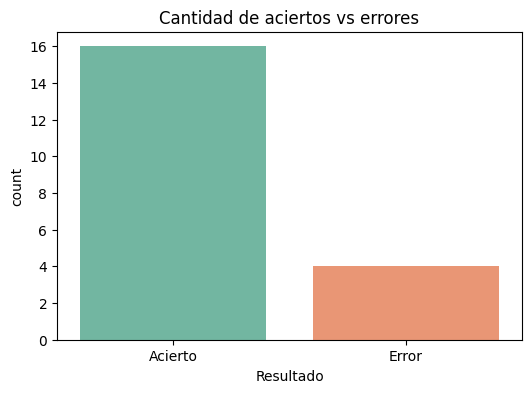

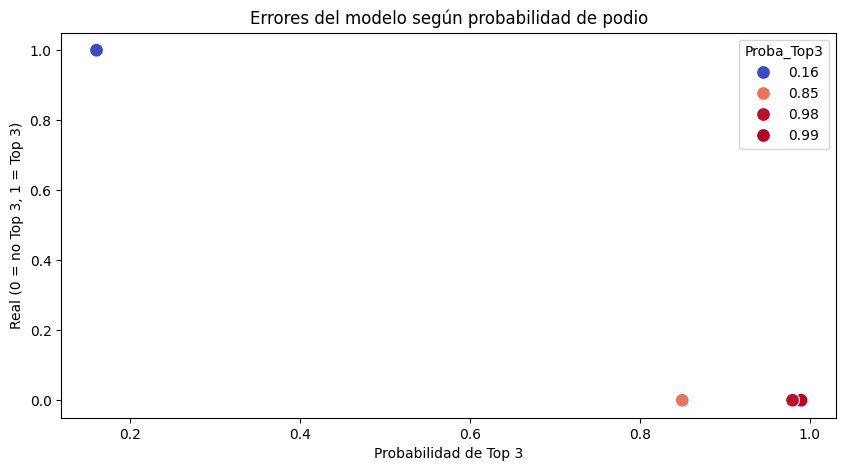

In [9]:
# Paso 1: Graficar la cantidad de errores y aciertos
plt.figure(figsize=(6,4))
sns.countplot(data=results_df, x='Resultado', palette='Set2')
plt.title('Cantidad de aciertos vs errores')
plt.show()

# Paso 2: Visualizar errores específicos en función de la probabilidad de podio
plt.figure(figsize=(10,5))
sns.scatterplot(data=errores_df, x='Proba_Top3', y='Real', hue='Proba_Top3', palette='coolwarm', s=100)
plt.title('Errores del modelo según probabilidad de podio')
plt.xlabel('Probabilidad de Top 3')
plt.ylabel('Real (0 = no Top 3, 1 = Top 3)')
plt.show()

## Matriz de confusión

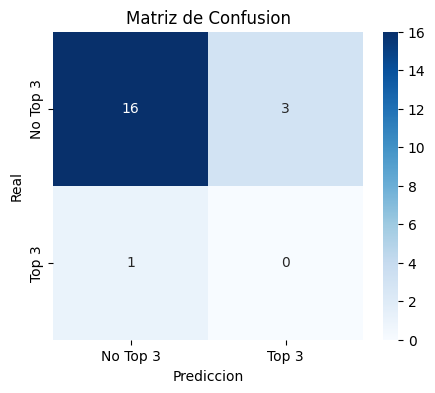

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Top 3', 'Top 3'],
            yticklabels=['No Top 3', 'Top 3'])
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.title('Matriz de Confusion')
plt.show()

Armar Dataframe con resultados

In [11]:
#Armar DataFrame con resultados
results_df = pd.DataFrame({
    'Real': y_test,
    'Prediccion':y_pred
})

results_df['Resultado'] = results_df.apply(
    lambda row: 'Acierto' if row['Real'] == row['Prediccion'] else 'Error', axis=1
)

C:\Users\Rolando Domínguez\AppData\Local\Temp\ipykernel_29536\1954863268.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=results_df, x='Resultado', palette='Set2')


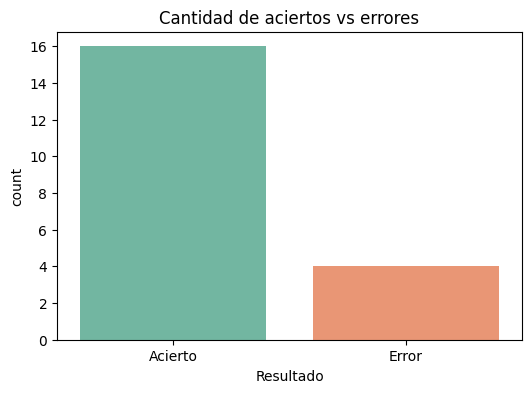

In [12]:
# Contamos cada tipo
plt.figure(figsize=(6,4))
sns.countplot(data=results_df, x='Resultado', palette='Set2')
plt.title('Cantidad de aciertos vs errores')
plt.show()

In [13]:
## Predicciones correctas por carrera
X_test = X_test.copy()
X_test['Actual'] = y_test.values
X_test['Predicted'] = y_pred
X_test['Correcto'] = X_test['Actual'] == X_test['Predicted']

# Merge con info de la carrera
X_merged = X_test.merge(df[['Race']], left_index=True, right_index=True)

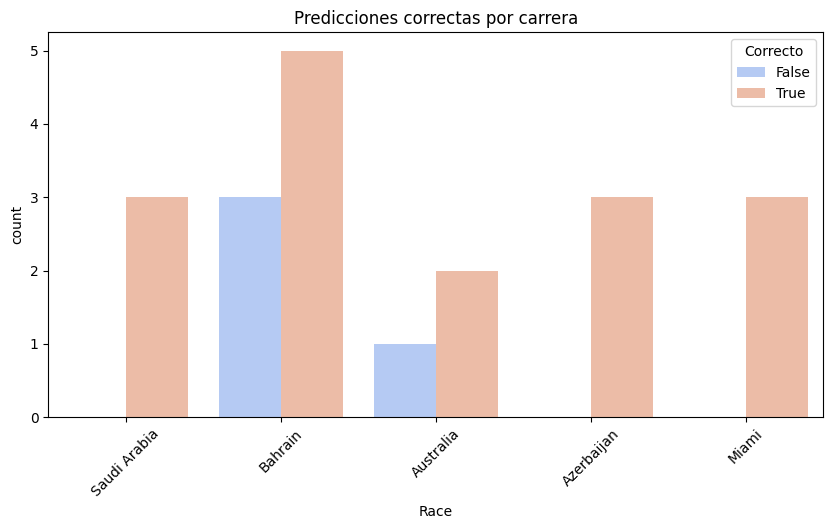

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(data=X_merged, x='Race', hue='Correcto', palette='coolwarm')
plt.title('Predicciones correctas por carrera')
plt.xticks(rotation=45)
plt.show()